In [33]:
from unstructured.partition.pdf import partition_pdf
# from unstructured.partition.auto import partition
from unstructured.documents.elements import Text,Element,FigureCaption,Image,Table
from dotenv import load_dotenv
import os
load_dotenv()

True

In [34]:
file_path = 'OLAP_and_OLTP.pdf'

raw_chunks = partition_pdf(
    filename=file_path,
    strategy="hi_res",
    infer_table_structure=True,
    extract_image_block_types=["figure", "table",'Image'],
    extract_image_block_to_payload=True,
    chunking_strategy=None,
)



In [35]:
raw_chunks

In [36]:
for idx, chunk in enumerate(raw_chunks):
    if isinstance(chunk, Image):
        print(f"Image {idx}")

Image 42


In [47]:
raw_chunks[42].to_dict()


{'type': 'Image',
 'element_id': '39577b87894266ab1d797cc045b3acf1',
 'text': 'Chicago Denver Dallas Me Markets Dimension Q1 Q2 7 Q3 Time Dimension',
 'metadata': {'coordinates': {'points': ((np.float64(492.8111805555555),
     np.float64(573.8405555555554)),
    (np.float64(492.8111805555555), np.float64(2313.658958333333)),
    (np.float64(3339.085069444444), np.float64(2313.658958333333)),
    (np.float64(3339.085069444444), np.float64(573.8405555555554))),
   'system': 'PixelSpace',
   'layout_width': 4094,
   'layout_height': 2893},
  'last_modified': '2026-03-18T14:52:37',
  'filetype': 'application/pdf',
  'languages': ['eng'],
  'page_number': 8,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg',
  'filename': 'OLAP_and_OLTP.pdf'}}

In [38]:
#you will observe that after image element we have figure caption element
raw_chunks[14].to_dict()

{'type': 'ListItem',
 'element_id': 'ce90a70547798e06d8272f2cf5207ab1',
 'text': 'Input Capture: User submits data (e.g., order details).',
 'metadata': {'detection_class_prob': 0.8250239491462708,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(281.15665277777777),
     np.float64(992.4761818734281)),
    (np.float64(281.15665277777777), np.float64(1084.9453092138683)),
    (np.float64(2396.681640625), np.float64(1084.9453092138683)),
    (np.float64(2396.681640625), np.float64(992.4761818734281))),
   'system': 'PixelSpace',
   'layout_width': 4094,
   'layout_height': 2893},
  'last_modified': '2026-03-18T14:52:37',
  'filetype': 'application/pdf',
  'languages': ['eng'],
  'page_number': 3,
  'filename': 'OLAP_and_OLTP.pdf',
  'parent_id': '6d806e2b19406bb110b3fb3b13b36411'}}

In [39]:
all_images = []
for idx, chunk in enumerate(raw_chunks):
    if isinstance(chunk, Image):
        # the next element after the image will be figure caption
        if idx + 1 < len(raw_chunks) and isinstance(raw_chunks[idx + 1], FigureCaption):
            caption = raw_chunks[idx + 1].text
        else:
            caption = "No caption found"

        all_images.append({
            "index": idx,
            "caption": caption if caption else "No caption found",
            "image_text": chunk.text,
            "base64": chunk.metadata.image_base64
        })


In [40]:
all_images

[{'index': 42,
  'caption': 'No caption found',
  'image_text': 'Chicago Denver Dallas Me Markets Dimension Q1 Q2 7 Q3 Time Dimension',
  'base64': '...'}]

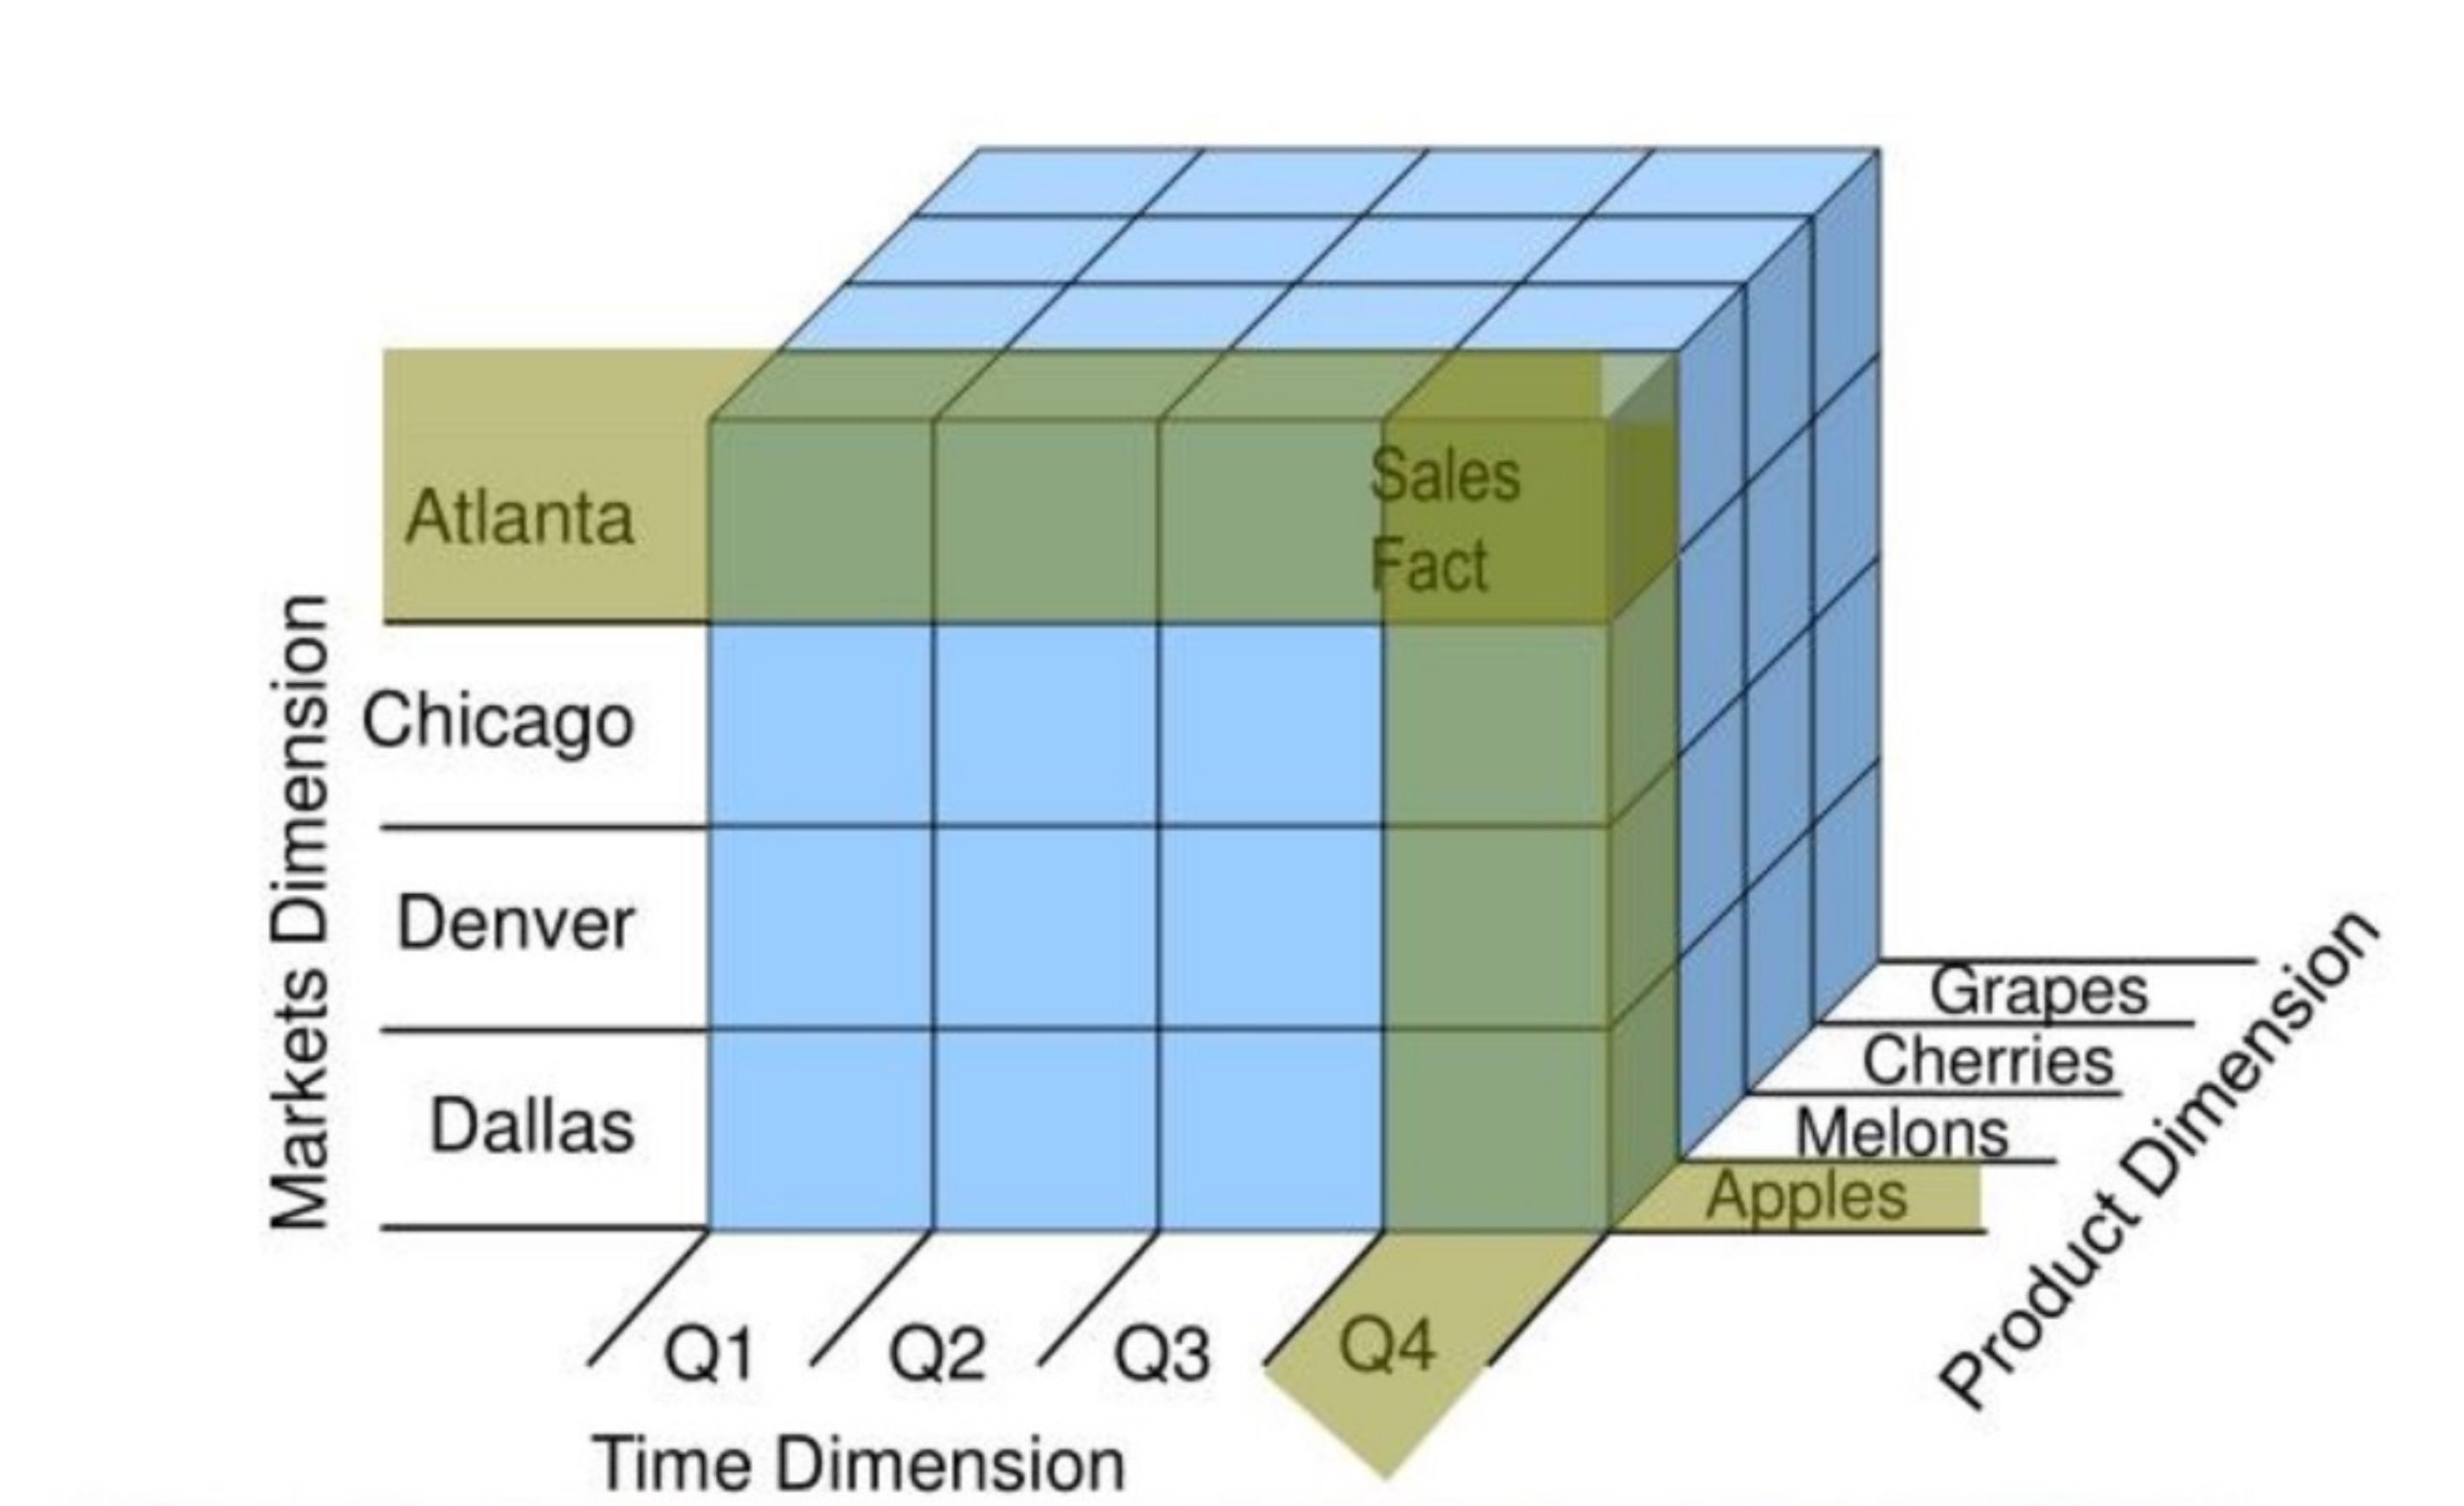

Caption: No caption found


In [41]:
import base64
from IPython.display import Image as IPImage, display
def display_image(image_dict):
    image_data = base64.b64decode(image_dict["base64"])
    display(IPImage(data=image_data, format='png'))
    print(f"Caption: {image_dict['caption']}")


for image_data in all_images:
    display_image(image_data)

### Image Captioning
very important process


In [42]:
# In multi modal rag , we get image data , now we have to ingest image data also in vector database. We can use CLIP model to get image embeddings and then store those embeddings in vector database along with text chunks. During retrieval we can retrieve both text and image chunks based on query similarity.
# or knowledge base , so that we can use that knowledge base for multi modal question answering.
# so we can create the discriptions as text and then ingest those discriptions in vector database along with image embeddings. During retrieval we can retrieve both text and image chunks based on query similarity.

# we can do either local llm or extenal llm for image captioning.
# we require image captioning for creating the discriptions for images,tables , figures etc.

from openai import OpenAI
from dotenv import load_dotenv
import os
load_dotenv()
client = OpenAI()

def generate_image_discription(image_dict):
    prompt = f"""
    Generate and describe the image in detail. 
    The caption of image is {image_dict['caption']} and the image text is {image_dict['image_text']}
    Directly analyze the image and provide a detailed description without any additional text.
    
    """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/png;base64,{image_dict['base64']}"},
                    },
                ],
            }
        ],
    )
    return response.choices[0].message.content

generate_image_discription(all_images[0])

'The image depicts a three-dimensional cube representing data across three dimensions: Markets Dimension, Time Dimension, and Product Dimension. \n\n- The **Markets Dimension** is represented vertically along the left side, listing four cities: Chicago, Denver, Dallas, and Atlanta (the latter positioned at the top within a green box).\n- The **Time Dimension** is displayed horizontally at the bottom, segmented into four quarters: Q1, Q2, Q3, and Q4.\n- The **Product Dimension** is oriented along the right side, featuring various fruits: Apples, Melons, Cherries, and Grapes. Apples are highlighted within a green box in the bottom section.\n\nThe cube\'s internal section labeled "Sales Fact" indicates a key focal point in the visualization, emphasizing sales data related to the intersections of the three dimensions. Each cell within the cube could represent data metrics such as sales volume or revenue for the specified combinations of cities, time periods, and products, although specific

### NOW will do table parsing

In [43]:
table_data = []
for idx , element in enumerate(raw_chunks):
    if isinstance(element, Table):
        table_data.append({
            "table_as_html":element.metadata.text_as_html
        })
        

In [44]:
table_data[0]

{'table_as_html': '<table><thead><tr><th>Category</th><th>OLAP (Online Analytical Processing)</th><th>OLTP (Online Transaction Processing)</th></tr></thead><tbody><tr><td>Data Source</td><td>Historical data from multiple databases.</td><td>Current operational data.</td></tr><tr><td>Purpose</td><td>Used for analysis and decision- making.</td><td>Used for day-to-day transactions.</td></tr><tr><td>Method Used</td><td>Uses a data warehouse.</td><td>Uses a standard DBMS.</td></tr><tr><td>Normalization</td><td>Tables are not normalized.</td><td>Tables are normalized (3NF).</td></tr><tr><td>Query Type</td><td>Complex, read-heavy queries</td><td>Simple, read/write queries</td></tr></tbody></table>'}

In [45]:
from IPython.display import HTML, display

def display_table(table_dict):
    html_content = table_dict["table_as_html"]
    display(HTML(html_content))

display_table(table_data[0])

Category,OLAP (Online Analytical Processing),OLTP (Online Transaction Processing)
Data Source,Historical data from multiple databases.,Current operational data.
Purpose,Used for analysis and decision- making.,Used for day-to-day transactions.
Method Used,Uses a data warehouse.,Uses a standard DBMS.
Normalization,Tables are not normalized.,Tables are normalized (3NF).
Query Type,"Complex, read-heavy queries","Simple, read/write queries"


In [48]:
# generate table description using llm
def generate_table_description(table_html):
    prompt = f"""
    Generate and describe the table in detailed descriptiton of its contents , includding the strucutre, 
    key data points , notable treands or insights 
    The table is {table_html}
    Directly analyze the table and provide a detailed description without any additional text.
    """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
    )
    return response.choices[0].message.content

print(generate_table_description(table_data[0]['table_as_html']))


The table is structured into two main sections: a header consisting of column titles and a body containing specific category entries. The columns are labeled "Category," "OLAP (Online Analytical Processing)," and "OLTP (Online Transaction Processing)." 

### Structure:
- **Header**: Contains three columns that categorize data into OLAP and OLTP systems.
- **Body**: Comprises five rows of distinct categories comparing OLAP and OLTP.

### Key Data Points:
1. **Data Source**: 
   - OLAP: Utilizes historical data aggregated from multiple databases, indicating its focus on long-term analysis.
   - OLTP: Works with current operational data, emphasizing real-time processing needs.

2. **Purpose**: 
   - OLAP is aimed at facilitating analysis and decision-making by summarizing and modeling data.
   - OLTP focuses on supporting day-to-day operational activities and transactions.

3. **Method Used**: 
   - OLAP employs a data warehouse architecture that accommodates vast amounts of data for anal

### Text parsing

In [49]:
text_chunks = partition_pdf(
    filename=file_path,
    strategy="hi_res",
    chunking_strategy="by_title",
    max_characters=2000,
    combine_text_under_n_chars=500,
    new_after_n_chars=1500
)

In [50]:
from unstructured.documents.elements import CompositeElement

for idx , chunk in enumerate(text_chunks):
    if isinstance(chunk, CompositeElement):
        print(f"chunk {idx}:{chunk.text[:50]}")

chunk 0:OLTP

• OLTP, i.e. Online Transaction Processing, 
chunk 1:OLTP:

ØWorking of OLTP:

• OLTP works by processi
chunk 2:OLTP:

ØStep-by-Step Process

Input Capture: User 
chunk 3:OLTP:

ØDrawbacks of OLTP Services

• Limited anal
chunk 4:OLAP:

• Most business data have multiple dimensio
chunk 5:OLAP:

ØBenefits of OLAP Services

OLAP offers sev
chunk 6:OLAP:

• Reduced Data Complexity: OLAP systems abs
chunk 7:OLAP vs OLTP:

• Difference between OLAP and OLTP

chunk 8:OLAP vs OLTP:

Category Data Volume Update Frequen
chunk 9:ØMultidimensional OLAP (MOLAP) Architecture:

MOLA
chunk 10:OLAP:

ØMeasures: Measures are the data values tha
chunk 11:OLAP:

ØRelational OLAP (ROLAP) Architecture

ROLA
chunk 12:OLAP:

Fact Tables: Fact tables store the measures
chunk 13:OLAP:

ØHybrid OLAP:

Hybrid online analytical pro
